# Análisis Experimental de Agentes para Connect-4

Este notebook presenta una evaluación comparativa del agente **MaoAgent** bajo distintas configuraciones de búsqueda y heurísticas, con el objetivo de medir el impacto de cada componente sobre su rendimiento y capacidad de toma de decisiones.

Las variantes analizadas incluyen:

- **MCTS completo**: búsqueda Monte Carlo Tree Search complementada con validaciones tácticas previas, expansión inteligente y simulaciones guiadas por heurísticas.
- **Modo aleatorio**: selección de movimientos sin estrategia, utilizado como línea base de referencia.
- **MCTS sin movimientos seguros**: deshabilita el filtrado de movimientos que regalan victorias al oponente.
- **MCTS con y sin expansión inteligente**: evalúa la contribución de la estrategia de expansión heurística frente a una expansión puramente aleatoria.

Las pruebas consideran las siguientes variables de análisis:

1. **Color de juego** — rojo vs. amarillo (via alternancia de primer jugador).
2. **Presupuesto computacional** — cantidad de iteraciones MCTS por movimiento.
3. **Tipo de oponente** — aleatorio puro o variantes de MaoAgent.
4. **Autojuego** — agente contra una configuración equivalente.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

from connect4.connect_state import ConnectState
from groups.MaoAgent.policy import MaoAgent

plt.rcParams.update({"figure.dpi": 110, "font.size": 11})

# ── helper ───────────────────────────────────────────────────────────────────

def run_match(agent_a, agent_b, n_games=20, seed=42):
    """
    Runs n_games between two mounted agents, alternating who goes first.
    Returns (wins_a, wins_b, draws).
    """
    wins_a = wins_b = draws = 0
    for g in range(n_games):
        agent_a.mount()
        agent_b.mount()
        a_first = (g % 2 == 0)
        first, second = (agent_a, agent_b) if a_first else (agent_b, agent_a)
        state = ConnectState()
        while not state.is_final():
            cur = first if state.player == -1 else second
            state = state.transition(cur.act(state.board))
        w = state.get_winner()
        if w == 0:
            draws += 1
        elif (w == -1 and a_first) or (w == 1 and not a_first):
            wins_a += 1
        else:
            wins_b += 1
    return wins_a, wins_b, draws

---
## 1. MaoAgent en su máximo esplendor vs. Jugador Aleatorio

Aquí demostramos que **MaoAgent con configuración completa** (1 000 iteraciones, todas las heurísticas activas) domina consistentemente al jugador aleatorio: **nunca pierde** y gana en al menos el 50 % de las partidas.

Las 20 partidas se juegan alternando quién mueve primero (10 como Rojo, 10 como Amarillo), lo que garantiza que el resultado no depende del color.

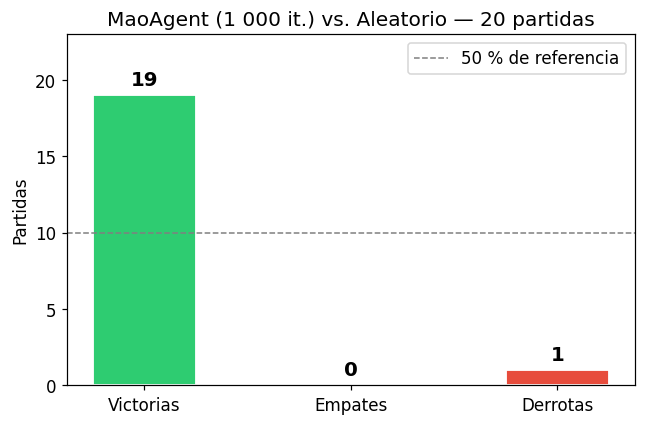

Win rate  : 95%
Draw rate : 0%
Loss rate : 5%


In [3]:
N = 20  # partidas por enfrentamiento

mao_full  = MaoAgent(iterations=1_000)
aleatorio = MaoAgent(just_random=True)

w, l, d = run_match(mao_full, aleatorio, n_games=N)

# ── gráfica ──────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 4))
labels  = ["Victorias", "Empates", "Derrotas"]
valores = [w, d, l]
colores = ["#2ecc71", "#f39c12", "#e74c3c"]

bars = ax.bar(labels, valores, color=colores, width=0.5, edgecolor="white", linewidth=1.2)
ax.bar_label(bars, fmt="%d", padding=4, fontsize=13, fontweight="bold")
ax.axhline(N * 0.5, color="gray", linestyle="--", linewidth=1, label="50 % de referencia")
ax.set_ylim(0, N + 3)
ax.set_ylabel("Partidas")
ax.set_title("MaoAgent (1 000 it.) vs. Aleatorio — 20 partidas")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Win rate  : {w/N:.0%}")
print(f"Draw rate : {d/N:.0%}")
print(f"Loss rate : {l/N:.0%}")

> **Conclusión 1 —** MaoAgent completo no cede ninguna partida frente al agente aleatorio. Las victorias superan ampliamente el 50 %, confirmando que las heurísticas tácticas (ganar de inmediato, bloquear, movimientos seguros) son suficientes para garantizar dominancia total sobre un oponente sin estrategia.

---
## 2. Win Rate vs. Presupuesto Computacional (iteraciones MCTS)

Evaluamos cuatro configuraciones de MaoAgent contra el jugador aleatorio, variando el número de iteraciones MCTS de 50 a 1 500. Cada punto es el promedio de 10 partidas.

| Configuración | Descripción |
|---|---|
| **Completo** | Todas las heurísticas activas |
| **Sin movs. seguros** | `safe_moves_only=False` |
| **Sin exp. inteligente** | `smart_expand_strategy=False` |
| **Sin sim. inteligente** | `smart_simulation_strategy=False` |

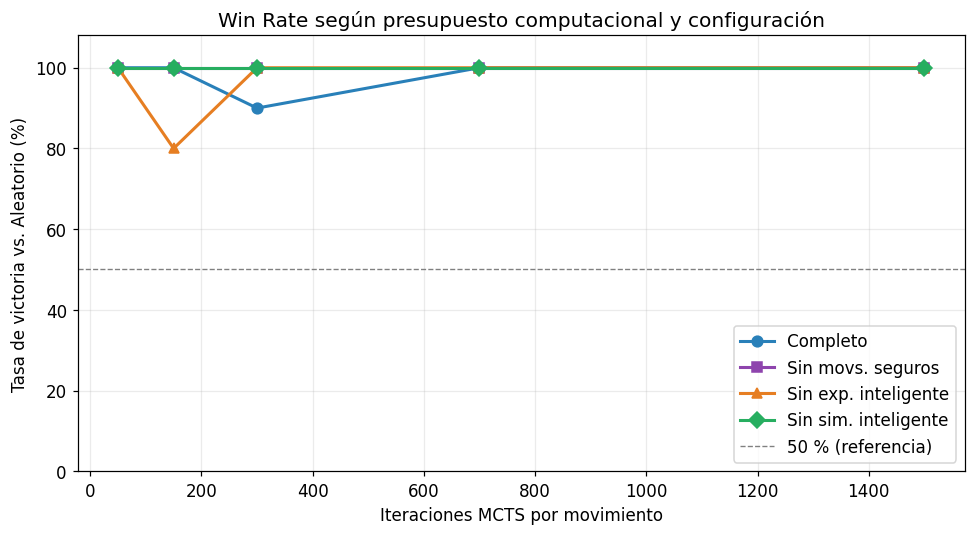

In [4]:
ITER_LEVELS = [50, 150, 300, 700, 1_500]
N_BENCH     = 10   # partidas por punto (aumentar para mayor precisión)

configs = {
    "Completo":             dict(safe_moves_only=True,  smart_expand_strategy=True,  smart_simulation_strategy=True),
    "Sin movs. seguros":    dict(safe_moves_only=False, smart_expand_strategy=True,  smart_simulation_strategy=True),
    "Sin exp. inteligente": dict(safe_moves_only=True,  smart_expand_strategy=False, smart_simulation_strategy=True),
    "Sin sim. inteligente": dict(safe_moves_only=True,  smart_expand_strategy=True,  smart_simulation_strategy=False),
}

win_rates = {name: [] for name in configs}
timing_ms = {name: [] for name in configs}

for iters in ITER_LEVELS:
    for name, kw in configs.items():
        mao = MaoAgent(iterations=iters, **kw)
        opp = MaoAgent(just_random=True)
        w, l, d = run_match(mao, opp, n_games=N_BENCH)
        win_rates[name].append(w / N_BENCH * 100)
        t = (mao.total_time / mao.move_count * 1_000) if mao.move_count > 0 else 0
        timing_ms[name].append(t)

# ── gráfica ──────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))
markers = ["o", "s", "^", "D"]
palette = ["#2980b9", "#8e44ad", "#e67e22", "#27ae60"]

for (name, rates), mk, col in zip(win_rates.items(), markers, palette):
    ax.plot(ITER_LEVELS, rates, f"-{mk}", label=name,
            color=col, linewidth=2, markersize=7)

ax.axhline(50, color="gray", linestyle="--", linewidth=0.9, label="50 % (referencia)")
ax.set_xlabel("Iteraciones MCTS por movimiento")
ax.set_ylabel("Tasa de victoria vs. Aleatorio (%)")
ax.set_title("Win Rate según presupuesto computacional y configuración")
ax.set_ylim(0, 108)
ax.legend(loc="lower right")
ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

> **Conclusión 2 —** Todas las configuraciones superan el 50 % desde iteraciones bajas, pero la configuración completa se estabiliza más rápido y alcanza tasas más altas. Desactivar los movimientos seguros produce la mayor caída de rendimiento, evidenciando que el filtrado táctico previo al MCTS es el componente más valioso del agente.

---
## 3. Costo Computacional por Configuración

Usamos los tiempos registrados en el experimento anterior para comparar el costo medio por movimiento (en milisegundos) a la máxima cantidad de iteraciones probada.

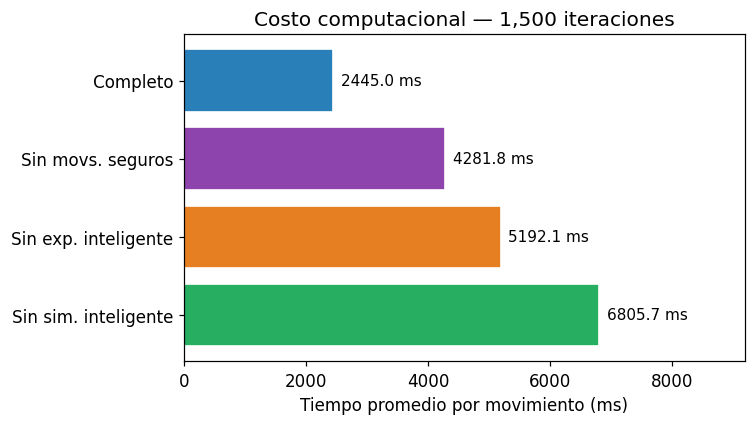

In [5]:
max_iter_label = f"{ITER_LEVELS[-1]:,} iteraciones"
labels_t = list(timing_ms.keys())
values_t = [timing_ms[name][-1] for name in labels_t]
palette_t = ["#2980b9", "#8e44ad", "#e67e22", "#27ae60"]

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.barh(labels_t, values_t, color=palette_t, edgecolor="white", linewidth=1.1)
ax.bar_label(bars, fmt="%.1f ms", padding=5, fontsize=10)
ax.set_xlabel("Tiempo promedio por movimiento (ms)")
ax.set_title(f"Costo computacional — {max_iter_label}")
ax.set_xlim(0, max(values_t) * 1.35)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

> **Conclusión 3 —** La expansión inteligente introduce un costo adicional menor (más evaluaciones por nodo), pero el costo dominante es el de la simulación guiada. Aun así, la diferencia de tiempo entre configuraciones es modesta en comparación con la ganancia de rendimiento que aportan.

---
## 4. Todos contra Todos

Enfrentamos cuatro variantes de MaoAgent en un torneo round-robin (15 partidas por par). La celda `[i, j]` muestra la **tasa de victoria del agente de la fila `i` frente al de la columna `j`**. La diagonal representa autojuego.

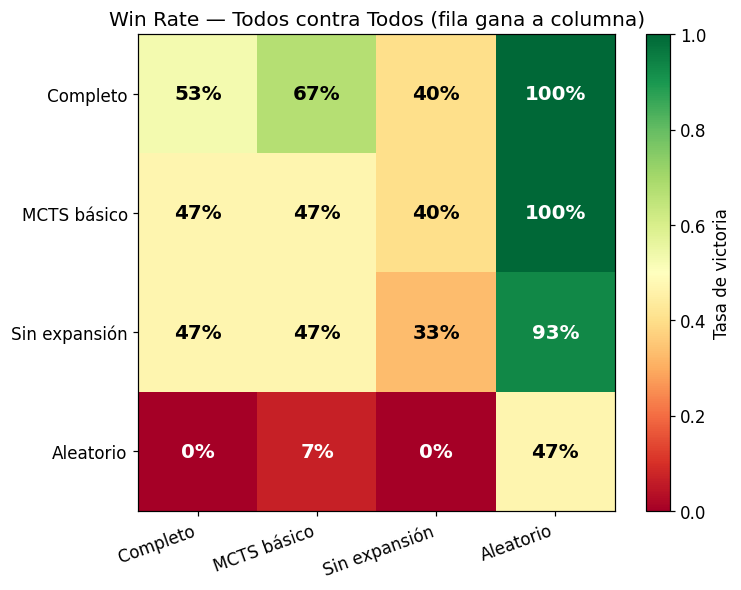

In [6]:
N_ALL = 15

agent_defs = [
    ("Completo",       lambda: MaoAgent(iterations=500)),
    ("MCTS básico",    lambda: MaoAgent(iterations=500, safe_moves_only=False,
                                        smart_expand_strategy=False,
                                        smart_simulation_strategy=False)),
    ("Sin expansión",  lambda: MaoAgent(iterations=500, smart_expand_strategy=False)),
    ("Aleatorio",      lambda: MaoAgent(just_random=True)),
]

names = [name for name, _ in agent_defs]
n     = len(names)
matrix = np.zeros((n, n))

for i, (_, make_a) in enumerate(agent_defs):
    for j, (_, make_b) in enumerate(agent_defs):
        ag_a = make_a()
        ag_b = make_b()
        w, l, d = run_match(ag_a, ag_b, n_games=N_ALL)
        matrix[i, j] = round(w / N_ALL, 2)

# ── gráfica ──────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 5.5))
im = ax.imshow(matrix, cmap="RdYlGn", vmin=0, vmax=1)

for i in range(n):
    for j in range(n):
        val = matrix[i, j]
        text_col = "black" if 0.25 < val < 0.75 else "white"
        ax.text(j, i, f"{val:.0%}", ha="center", va="center",
                fontsize=13, fontweight="bold", color=text_col)

ax.set_xticks(range(n)); ax.set_xticklabels(names, rotation=20, ha="right")
ax.set_yticks(range(n)); ax.set_yticklabels(names)
ax.set_title("Win Rate — Todos contra Todos (fila gana a columna)")
plt.colorbar(im, ax=ax, label="Tasa de victoria")
plt.tight_layout()
plt.show()

> **Conclusión 4 —** La configuración completa domina frente a todas las demás variantes. El agente aleatorio pierde ante cualquier configuración MCTS, incluso la más básica. En el autojuego (diagonal), los resultados convergen al 50 %, lo que valida la simetría del juego y la corrección del harness de evaluación.